# Load n matches from the events folder to generate shots



In [47]:
import pandas as pd
import numpy as np

In [48]:
import json

def getAllShotsInMatch(matchEventDf):
    df = matchEventDf.copy()
    df.drop(['ball_receipt', 'ball_recovery', 'carry', 'counterpress', 'dribble', 'duel', 'goalkeeper', 'interception', 'pass', 'substitution', 'type'], axis=1, inplace=True)
    try:
        df.drop(['bad_behaviour', 'block', 'injury_stoppage', 'foul_committed', 'foul_won', 'tactics'])
    except:
        pass
    return df.dropna(subset=['shot'])

def getPlayerPositionsDuringShots(shot):
    frame = shot["freeze_frame"]
    otherPlayerPositions = []

    for player in frame:
        playerDict = {}
        playerDict["location"] = player["location"]
        playerDict["position"] = player["position"]["name"]
        playerDict["teammate"] = player["teammate"]
        otherPlayerPositions.append(playerDict)
    
    return otherPlayerPositions

def addToDict(record, dictionary, cols):
    for col in cols:
        dictionary[col] = record[col] if col in record else None

In [49]:
#shot dataframe
shotDfCols = ["end_location", "aerial_won", "follows_dribble", "first_time", "open_goal", "deflected", "body_part", "type", "technique", "outcome", "statsbomb_xg"]
shotRowDfCols = ["player", "position", "location", "under_pressure"]
shotCompositeDfCols = ["player_positions"]

In [61]:
# load shots from first 100 matches
import os

listOfShots = []

# get list of all files in events directory
eventFiles = os.listdir("data/events")
for i in range (100):
    with open(f'data/events/{eventFiles[i]}', 'r') as match:
        match1 = []
        events = json.load(match)
        for item in events:
            match1.append(item)

    matchEventDf = pd.DataFrame(match1)
    allShotsInMatch = getAllShotsInMatch(matchEventDf)

    for row in allShotsInMatch.iloc:
        shot = row["shot"]

        shotDict = {}
        addToDict(shot, shotDict, shotDfCols)
        addToDict(row, shotDict, shotRowDfCols)

        shotDict["type"] = shot["type"]["name"]
        shotDict["body_part"] = shot["body_part"]["name"]
        shotDict["technique"] = shot["technique"]["name"]
        shotDict["outcome"] = shot["outcome"]["name"]

        try:
            shotDict["player_positions"] = getPlayerPositionsDuringShots(shot)
        except:
            shotDict["player_positions"] = []

        listOfShots.append(shotDict)

listOfShotsDf = pd.DataFrame(listOfShots)
listOfShotsDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2487 entries, 0 to 2486
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   end_location      2487 non-null   object 
 1   aerial_won        212 non-null    object 
 2   follows_dribble   3 non-null      object 
 3   first_time        752 non-null    object 
 4   open_goal         31 non-null     object 
 5   deflected         26 non-null     object 
 6   body_part         2487 non-null   object 
 7   type              2487 non-null   object 
 8   technique         2487 non-null   object 
 9   outcome           2487 non-null   object 
 10  statsbomb_xg      2487 non-null   float64
 11  player            2487 non-null   object 
 12  position          2487 non-null   object 
 13  location          2487 non-null   object 
 14  under_pressure    641 non-null    object 
 15  player_positions  2487 non-null   object 
dtypes: float64(1), object(15)
memory usage: 31

# Exploratory data analysis on shots

Text(0.5, 1.0, 'Shot Outcome')

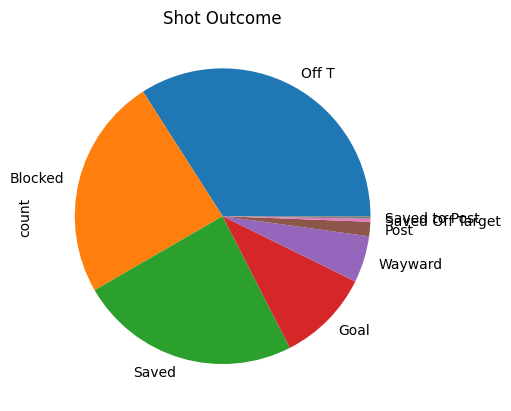

In [53]:
import matplotlib.pyplot as plt

# shot outcome bar chart
listOfShotsDf["outcome"].value_counts().plot(kind='pie')
# titles on the side

plt.title("Shot Outcome")

Text(0.5, 1.0, 'Shot Technique')

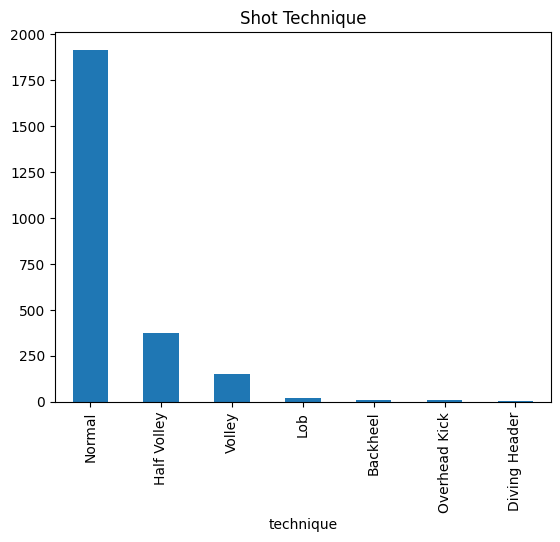

In [54]:
listOfShotsDf["technique"].value_counts().plot(kind='bar')
plt.title("Shot Technique")

Text(0.5, 1.0, 'Shot Body Part')

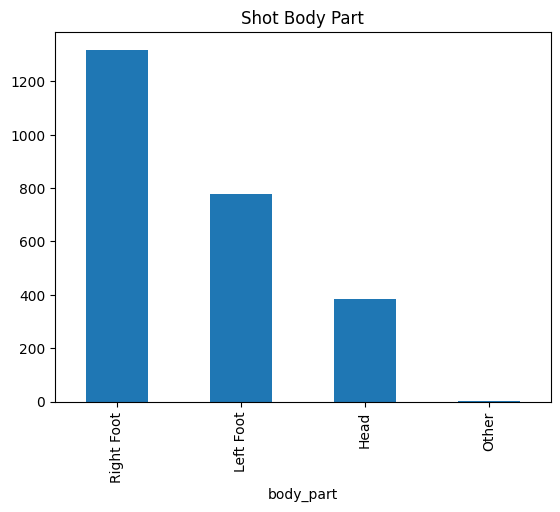

In [55]:
listOfShotsDf["body_part"].value_counts().plot(kind='bar')
plt.title("Shot Body Part")

In [56]:
listOfShotsDf.iloc[0]["type"]

'Open Play'

# CALCULATE pre-shot XG and post-shot XG
Pre-shot xG params:
- aerial_won
- follows_dribble
- first_time
- open_goal
- body_part
- type
- technique
- position
- location
- under_pressure
- player_positions

Post-shot xG params:
- The above
- end_location
- deflected
- outcome

# Encodings:
Body part:

0. Right foot
1. Left foot
2. Head
3. Other

Type:

0. Open play
1. Free kick
2. Penalty
3. Other

Technique:

0. Normal
1. Half Volley
2. Volley
3. Lob
4. Diving header
5. Backheel
6. Overhead kick

Numbers: as ID'ed.


In [62]:
from sklearn.model_selection import train_test_split

# encode categorical cols as numbers
# replace body part with ids
bodyPartMap = {"Right Foot": 0, "Left Foot": 1, "Head": 2, "Other": 3}
typeMap = {"Open Play": 0, "Free Kick": 1, "Penalty": 2, "Other": 3}
techniqueMap = {"Normal": 0, "Volley": 1, "Half Volley": 2, "Lob": 3, "Diving Header": 4, "Overhead Kick": 5, "Backheel": 6}
positionMap = {"Goalkeeper": 1, "Right Back": 2, "Right Center Back": 3, "Center Back": 4, "Left Center Back": 5, "Left Back": 6, "Right Wing Back": 7, "Left Wing Back": 8, "Right Defensive Midfield": 9, "Center Defensive Midfield": 10, "Left Defensive Midfield": 11, "Right Midfield": 12, "Right Center Midfield": 13, "Center Midfield": 14, "Left Center Midfield": 15, "Left Midfield": 16, "Right Wing": 17, "Right Attacking Midfield": 18, "Center Attacking Midfield": 19, "Left Attacking Midfield": 20, "Left Wing": 21, "Right Center Forward": 22, "Center Forward": 23, "Left Center Forward": 24, "Secondary Striker": 25}

listOfShotsDf["body_part"] = listOfShotsDf["body_part"].map(bodyPartMap)
listOfShotsDf["type"] = listOfShotsDf["type"].map(typeMap)
listOfShotsDf["technique"] = listOfShotsDf["technique"].map(techniqueMap)

listOfShotsDf["position"] = listOfShotsDf["position"].apply(lambda x: positionMap[x['name']] if x['name'] in positionMap else 0)

#w['female'][w['female'] == 'female']=1

In [68]:
# convert all locations to x and y cols
listOfShotsDf["location_x"] = listOfShotsDf["location"].apply(lambda x: x[0])
listOfShotsDf["location_y"] = listOfShotsDf["location"].apply(lambda x: x[1])
listOfShotsDf["end_location_x"] = listOfShotsDf["end_location"].apply(lambda x: x[0])
listOfShotsDf["end_location_y"] = listOfShotsDf["end_location"].apply(lambda x: x[1])

# drop location cols
listOfShotsDf.drop(["location", "end_location"], axis=1, inplace=True)

In [89]:
# add False to all empty cols
listOfShotsDf["aerial_won"].fillna(False, inplace=True)
listOfShotsDf["follows_dribble"].fillna(False, inplace=True)
listOfShotsDf["first_time"].fillna(False, inplace=True)
listOfShotsDf["open_goal"].fillna(False, inplace=True)
listOfShotsDf["deflected"].fillna(False, inplace=True)

/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_71964/3399495894.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listOfShotsDf["aerial_won"].fillna(False, inplace=True)
/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_71964/3399495894.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  

In [94]:
listOfShotsDf["under_pressure"].fillna(False, inplace=True)

/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_71964/2237856647.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listOfShotsDf["under_pressure"].fillna(False, inplace=True)
/var/folders/h_/lg0zhls57_l_8r2q6kbmsszw0000gn/T/ipykernel_71964/2237856647.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)

In [95]:
# set up pre-shot xG df
preShotXgDf = listOfShotsDf.copy()
preShotXgDf.drop(['end_location_x', 'end_location_y', 'deflected', 'outcome', 'player'], axis=1, inplace=True)

# get statsbomb_xg as target - remove positions for now!
y = preShotXgDf["statsbomb_xg"]
X = preShotXgDf.drop(["statsbomb_xg", "player_positions"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [96]:
def percentageDifference(pred, actual):
    return (abs(pred - actual) / actual) * 100

# Decision Tree Regressor

In [107]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Initialize DecisionTreeRegressor
decision_tree = DecisionTreeRegressor(random_state=42)

# Fit the model
decision_tree.fit(X_train, y_train)

# Predict on the test set
y_pred_decision_tree = decision_tree.predict(X_test)

# Evaluate with mean squared error
mse = mean_squared_error(y_test, y_pred_decision_tree)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.009372885762318053


Feature importances: 
type: 0.35612510644207374
location_x: 0.20040561370812013
open_goal: 0.19253928539411572
location_y: 0.15027550423494818
position: 0.029821916406487216
body_part: 0.02823150559087724
technique: 0.025138423353647906
under_pressure: 0.007146361684207138
first_time: 0.006374430600579839
aerial_won: 0.0039418525849428745
follows_dribble: 0.0


<BarContainer object of 11 artists>

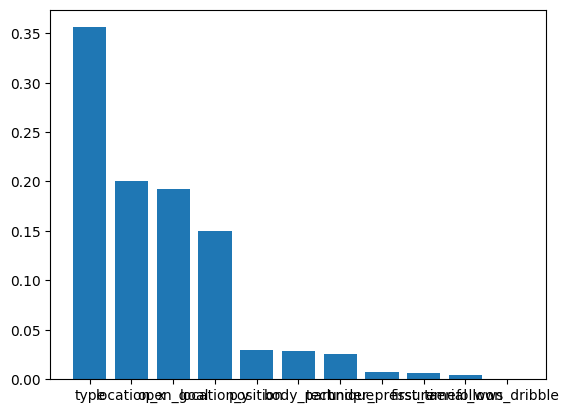

In [102]:
# get the feature importances
importances = decision_tree.feature_importances_
features = X.columns

# sort the features by importance
indices = np.argsort(importances)[::-1]
features = [features[i] for i in indices]
importances = [importances[i] for i in indices]

print("Feature importances: ")
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance}")

plt.bar(features, importances)


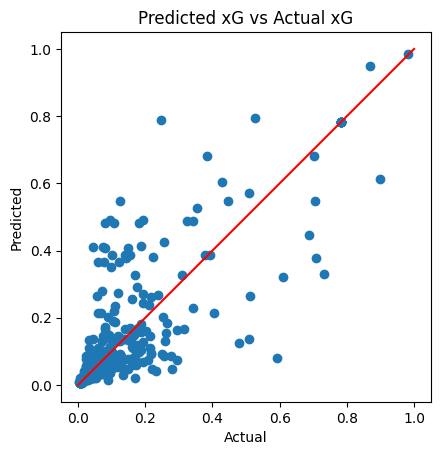

In [111]:
# create a scatter plot of the predictions vs actual values
plt.scatter(y_test, y_pred_decision_tree)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted xG vs Actual xG")
plt.gca().set_aspect('equal', adjustable='box')

# trendline of y = x
trendline = np.linspace(0, 1, 100)
plt.plot(trendline, trendline, color='red')


In [115]:
# create new df with predicted xG and actual xG
decisionTreeXgDf = pd.DataFrame({"actual": y_test, "predicted": y_pred_decision_tree})
decisionTreeXgDf["percent_diff"] = decisionTreeXgDf.apply(lambda x: percentageDifference(x["predicted"], x["actual"]), axis=1)
decisionTreeXgDf["abs_diff"] = decisionTreeXgDf.apply(lambda x: abs(x["predicted"] - x["actual"]), axis=1)

# how many predictions are within 0.01 of the actual value
dTreeLessThan01 = decisionTreeXgDf[decisionTreeXgDf["abs_diff"] <= 0.01]
print(f"Within 0.01 xG of actual value: {len(dTreeLessThan01)} ({len(dTreeLessThan01) / len(decisionTreeXgDf) * 100}%)")

# get median absolute difference and median percentage difference
medianAbsDiff = decisionTreeXgDf["abs_diff"].median()
medianPercentDiff = decisionTreeXgDf["percent_diff"].median()

print(f"Median Absolute Difference: {medianAbsDiff}")
print(f"Median Percentage Difference: {medianPercentDiff}")

Within 0.01 xG of actual value: 217 (43.57429718875502%)
Median Absolute Difference: 0.013712812999999997
Median Percentage Difference: 28.243896555887353


# Random Forest Regressor

In [116]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_random_forest = random_forest.predict(X_test)

mse = mean_squared_error(y_test, y_pred_random_forest)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 0.004831945576546075


In [118]:
# evaluation functions

# get the feature importances
def getFeatureImportances(model, X):
    importances = model.feature_importances_
    features = X.columns

    # sort the features by importance
    indices = np.argsort(importances)[::-1]
    features = [features[i] for i in indices]
    importances = [importances[i] for i in indices]

    print("Feature importances: ")
    for feature, importance in zip(features, importances):
        print(f"{feature}: {importance}")

    plt.bar(features, importances)

    return features, importances

# create a scatter plot of the predictions vs actual values
def plotPredictionsVsActual(y_test, y_pred):
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Predicted xG vs Actual xG")
    plt.gca().set_aspect('equal', adjustable='box')

    # trendline of y = x
    trendline = np.linspace(0, 1, 100)
    plt.plot(trendline, trendline, color='red')

# create new df with predicted xG and actual xG
def createXgDf(y_test, y_pred):
    xgDf = pd.DataFrame({"actual": y_test, "predicted": y_pred})
    xgDf["percent_diff"] = xgDf.apply(lambda x: percentageDifference(x["predicted"], x["actual"]), axis=1)
    xgDf["abs_diff"] = xgDf.apply(lambda x: abs(x["predicted"] - x["actual"]), axis=1)

    return xgDf

# how many predictions are within threshold of the actual value
def getWithinThreshold(xgDf, threshold):
    withinThreshold = xgDf[xgDf["abs_diff"] <= threshold]
    print(f"Within {threshold} xG of actual value: {len(withinThreshold)} ({len(withinThreshold) / len(xgDf) * 100}%)")

    return withinThreshold

# get median absolute difference and median percentage difference
def getMedians(xgDf):
    medianAbsDiff = xgDf["abs_diff"].median()
    medianPercentDiff = xgDf["percent_diff"].median()

    print(f"Median Absolute Difference: {medianAbsDiff}")
    print(f"Median Percentage Difference: {medianPercentDiff}")

    return medianAbsDiff, medianPercentDiff


Feature importances: 
type: 0.3538915703926688
open_goal: 0.1962533348523876
location_x: 0.18701793727763194
location_y: 0.15060977550744375
position: 0.036110315887535153
body_part: 0.03054429382585869
technique: 0.022069848092239205
under_pressure: 0.008189644679106389
first_time: 0.007899949329651176
aerial_won: 0.007413264534416575
follows_dribble: 6.56210608153911e-08


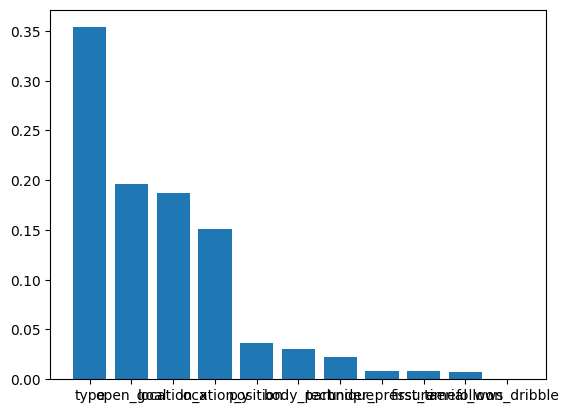

In [120]:
rf_features, rf_importances = getFeatureImportances(random_forest, X)

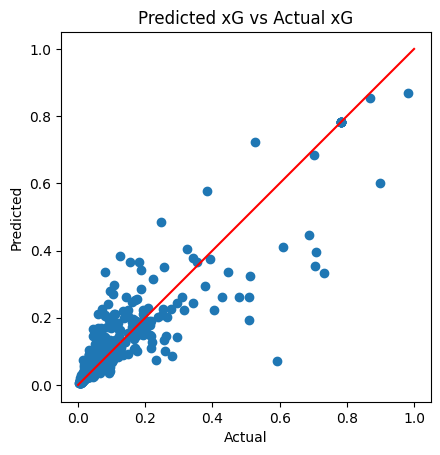

In [121]:
randomForestXgDf = createXgDf(y_test, y_pred_random_forest)
plotPredictionsVsActual(y_test, y_pred_random_forest)

In [122]:
getWithinThreshold(randomForestXgDf, 0.01)

Within 0.01 xG of actual value: 218 (43.77510040160642%)


,actual,predicted,percent_diff,abs_diff
1487,0.070411,0.063434,9.908577,0.006977
1383,0.028482,0.028051,1.514324,0.000431
1645,0.051216,0.044604,12.910597,0.006612
163,0.077961,0.087307,11.988055,0.009346
1910,0.028457,0.028113,1.206710,0.000343
...,...,...,...,...
370,0.033617,0.030124,10.390050,0.003493
1376,0.006060,0.014237,134.947877,0.008178
1947,0.072786,0.068099,6.439993,0.004687
1526,0.057894,0.059010,1.928495,0.001116


In [123]:
getMedians(randomForestXgDf)

Median Absolute Difference: 0.01276925184499999
Median Percentage Difference: 25.057070592126454


(np.float64(0.01276925184499999), np.float64(25.057070592126454))